In [1]:
pip install pandas numpy scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow.keras.backend as K
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

seed = 9001
np.random.seed(seed)
tf.random.set_seed(seed)

print("TensorFlow version:", tf.__version__)

2026-04-07 16:05:12.313374: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775577912.544014      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775577912.608347      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775577913.128824      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775577913.128869      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775577913.128872      17 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


In [3]:
INPUT_PATH = "/kaggle/input/datasets/thuhiuhong/lstm-new-train-test-val-2"

X_train = np.load(os.path.join(INPUT_PATH, "X_train.npy"))
X_val   = np.load(os.path.join(INPUT_PATH, "X_val.npy"))
X_test  = np.load(os.path.join(INPUT_PATH, "X_test.npy"))

y_train_vital = np.load(os.path.join(INPUT_PATH, "y_train_vital.npy"))
y_val_vital   = np.load(os.path.join(INPUT_PATH, "y_val_vital.npy"))
y_test_vital  = np.load(os.path.join(INPUT_PATH, "y_test_vital.npy"))

y_train_vital_mask = np.load(os.path.join(INPUT_PATH, "y_train_vital_mask.npy"))
y_val_vital_mask   = np.load(os.path.join(INPUT_PATH, "y_val_vital_mask.npy"))
y_test_vital_mask  = np.load(os.path.join(INPUT_PATH, "y_test_vital_mask.npy"))

In [4]:
X_train = X_train.astype(np.float32)
X_val   = X_val.astype(np.float32)
X_test  = X_test.astype(np.float32)

y_train_vital = y_train_vital.astype(np.float32)
y_val_vital   = y_val_vital.astype(np.float32)
y_test_vital  = y_test_vital.astype(np.float32)

y_train_vital_mask = y_train_vital_mask.astype(np.float32)
y_val_vital_mask   = y_val_vital_mask.astype(np.float32)
y_test_vital_mask  = y_test_vital_mask.astype(np.float32)

print("X_train:", X_train.shape, X_train.dtype)
print("X_val:", X_val.shape, X_val.dtype)
print("X_test:", X_test.shape, X_test.dtype)

print("y_train_vital:", y_train_vital.shape, y_train_vital.dtype)
print("y_train_vital_mask:", y_train_vital_mask.shape, y_train_vital_mask.dtype)

assert X_train.ndim == 3
assert X_val.ndim == 3
assert X_test.ndim == 3

assert len(X_train) == len(y_train_vital) == len(y_train_vital_mask)
assert len(X_val) == len(y_val_vital) == len(y_val_vital_mask)
assert len(X_test) == len(y_test_vital) == len(y_test_vital_mask)

N_VITAL = y_train_vital.shape[1]
print("N_VITAL =", N_VITAL)

# ghép target và mask lại để loss đọc được
y_train_vital_pack = np.concatenate([y_train_vital, y_train_vital_mask], axis=1).astype(np.float32)
y_val_vital_pack   = np.concatenate([y_val_vital, y_val_vital_mask], axis=1).astype(np.float32)
y_test_vital_pack  = np.concatenate([y_test_vital, y_test_vital_mask], axis=1).astype(np.float32)

print("y_train_vital_pack:", y_train_vital_pack.shape)
print("y_val_vital_pack:", y_val_vital_pack.shape)
print("y_test_vital_pack:", y_test_vital_pack.shape)

X_train: (119140, 10, 133) float32
X_val: (30003, 10, 133) float32
X_test: (37276, 10, 133) float32
y_train_vital: (119140, 8) float32
y_train_vital_mask: (119140, 8) float32
N_VITAL = 8
y_train_vital_pack: (119140, 16)
y_val_vital_pack: (30003, 16)
y_test_vital_pack: (37276, 16)


In [5]:
def masked_mse(y_true_pack, y_pred):
    y_true = y_true_pack[:, :N_VITAL]
    mask   = y_true_pack[:, N_VITAL:]

    se = tf.square(y_true - y_pred) * mask
    denom = tf.reduce_sum(mask) + 1e-8
    return tf.reduce_sum(se) / denom

In [6]:
BEST_UNITS = 16
BEST_DROPOUT = 0.3
BEST_BATCH = 512
LEARNING_RATE = 1e-3
EPOCHS = 30

print("BEST_UNITS =", BEST_UNITS)
print("BEST_DROPOUT =", BEST_DROPOUT)
print("BEST_BATCH =", BEST_BATCH)
print("LEARNING_RATE =", LEARNING_RATE)
print("EPOCHS =", EPOCHS)

BEST_UNITS = 16
BEST_DROPOUT = 0.3
BEST_BATCH = 512
LEARNING_RATE = 0.001
EPOCHS = 30


In [7]:
def build_encoder(n_lstm_units, dropout_rate, input_shape):
    inputs = Input(shape=input_shape, name='encoder_input')

    x = Bidirectional(
        LSTM(n_lstm_units, return_sequences=True),
        name='bilstm_1'
    )(inputs)
    x = Dropout(dropout_rate, name='dropout_1')(x)
    x = BatchNormalization(name='bn_1')(x)

    x = Bidirectional(
        LSTM(max(n_lstm_units // 2, 8), return_sequences=False),
        name='bilstm_2'
    )(x)
    x = Dropout(dropout_rate, name='dropout_2')(x)
    x = BatchNormalization(name='bn_2')(x)

    shared = Dense(16, activation='relu', name='shared_dense')(x)

    encoder = Model(inputs, shared, name='encoder')
    return encoder

In [8]:
def build_vital_pretrain_model(n_lstm_units, dropout_rate, input_shape, n_vital):
    encoder = build_encoder(n_lstm_units, dropout_rate, input_shape)

    inputs = encoder.input
    shared = encoder.output

    vital_out = Dense(n_vital, activation='linear', name='vital')(shared)

    model = Model(inputs, vital_out, name='vital_pretrain_model')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=masked_mse
    )

    return model, encoder

In [9]:
pretrain_model, encoder = build_vital_pretrain_model(
    n_lstm_units=BEST_UNITS,
    dropout_rate=BEST_DROPOUT,
    input_shape=(X_train.shape[1], X_train.shape[2]),
    n_vital=N_VITAL
)

pretrain_model.summary()

2026-04-07 16:05:43.910392: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "vital_pretrain_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 10, 133)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 10, 32)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 10, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 16)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ shared_dense (Dense)            │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vital (Dense)                   │ (None, 8)              │           136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,424 (87.59 KB)

 Trainable params: 22,328 (87.22 KB)

 Non-trainable params: 96 (384.00 B)

In [10]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

checkpoint = ModelCheckpoint(
    '/kaggle/working/best_vital_pretrain_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [11]:
history = pretrain_model.fit(
    X_train,
    y_train_vital_pack,
    validation_data=(X_val, y_val_vital_pack),
    epochs=EPOCHS,
    batch_size=BEST_BATCH,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    shuffle=True,
    verbose=1
)

Epoch 1/30
232/233 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.6173
Epoch 1: val_loss improved from inf to 0.24153, saving model to /kaggle/working/best_vital_pretrain_model.keras
233/233 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: 0.6157 - val_loss: 0.2415 - learning_rate: 0.0010
Epoch 2/30
232/233 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.2382
Epoch 2: val_loss improved from 0.24153 to 0.17918, saving model to /kaggle/working/best_vital_pretrain_model.keras
233/233 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.2381 - val_loss: 0.1792 - learning_rate: 0.0010
Epoch 3/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1948
Epoch 3: val_loss improved from 0.17918 to 0.15962, saving model to /kaggle/working/best_vital_pretrain_model.keras
233/233 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.1947 - val_loss: 0.1596 - learning_rate: 0.0010
Epoch 4/30
232/233 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1750
Epoch 4: val_loss improved from 0.15962 to 0.15050, saving model to /kaggle/working

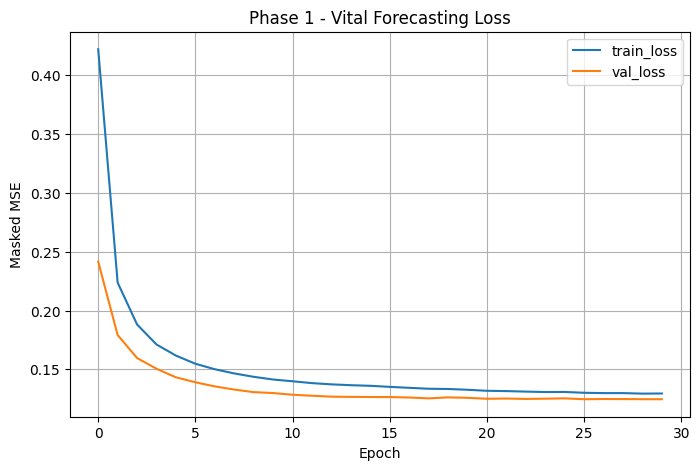

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Phase 1 - Vital Forecasting Loss')
plt.xlabel('Epoch')
plt.ylabel('Masked MSE')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
test_loss = pretrain_model.evaluate(X_test, y_test_vital_pack, batch_size=BEST_BATCH, verbose=1)
print("Phase 1 Test Loss (masked MSE):", test_loss)

73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1275
Phase 1 Test Loss (masked MSE): 0.1257219910621643


In [14]:
encoder.save_weights('/kaggle/working/encoder_pretrained_vital.weights.h5')
print("✅ Đã lưu encoder weights")

✅ Đã lưu encoder weights


In [15]:
pretrain_model.save('/kaggle/working/vital_pretrain_model.keras')
print("✅ Đã lưu full pretrain model")

✅ Đã lưu full pretrain model
